## DDPM 

Denoising Diffusion Probabilistic Model with PyTorch implementation

### References
- https://github.com/hojonathanho/diffusion
- https://github.com/lucidrains/denoising-diffusion-pytorch
- https://github.com/openai/improved-diffusion/
- https://arxiv.org/abs/2006.11239
- https://huggingface.co/blog/annotated-diffusion


In [8]:
import os
import math
from abc import abstractmethod

from PIL import Image
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

%matplotlib inline

In [9]:
# use sinusoidal position embedding to encode time step (https://arxiv.org/abs/1706.03762)   
def timestep_embedding(timesteps, dim, max_period=10000):
    """
    Create sinusoidal timestep embeddings.
    :param timesteps: a 1-D Tensor of N indices, one per batch element.
                      These may be fractional.
    :param dim: the dimension of the output.
    :param max_period: controls the minimum frequency of the embeddings.
    :return: an [N x dim] Tensor of positional embeddings.
    """
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
    ).to(device=timesteps.device)
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

In [10]:
# define TimestepEmbedSequential to support `time_emb` as extra input
class TimestepBlock(nn.Module):
    """
    Any module where forward() takes timestep embeddings as a second argument.
    """

    @abstractmethod
    def forward(self, x, emb):
        """
        Apply the module to `x` given `emb` timestep embeddings.
        """


class TimestepEmbedSequential(nn.Sequential, TimestepBlock):
    """
    A sequential module that passes timestep embeddings to the children that
    support it as an extra input.
    """

    def forward(self, x, emb):
        for layer in self:
            if isinstance(layer, TimestepBlock):
                x = layer(x, emb)
            else:
                x = layer(x)
        return x

# use GN for norm layer
def norm_layer(channels):
    return nn.GroupNorm(32, channels)

In [11]:
# Residual block
class ResidualBlock(TimestepBlock):
    def __init__(self, in_channels, out_channels, time_channels, dropout):
        super().__init__()
        self.conv1 = nn.Sequential(
            norm_layer(in_channels),
            nn.SiLU(), 
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        )
        
        # pojection for time step embedding
        self.time_emb = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_channels, out_channels)
        )
        
        self.conv2 = nn.Sequential(
            norm_layer(out_channels),
            nn.SiLU(),
            nn.Dropout(p=dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        )

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()


    def forward(self, x, t):
        """
        `x` has shape `[batch_size, in_dim, height, width]`
        `t` has shape `[batch_size, time_dim]`
        """
        h = self.conv1(x)
        # Add time step embeddings
        h += self.time_emb(t)[:, :, None, None]
        h = self.conv2(h)
        return h + self.shortcut(x)

In [12]:
# Attention block with shortcut
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=1):
        super().__init__()
        self.num_heads = num_heads
        assert channels % num_heads == 0
        
        self.norm = norm_layer(channels)
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1, bias=False)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x))
        q, k, v = qkv.reshape(B*self.num_heads, -1, H*W).chunk(3, dim=1)
        scale = 1. / math.sqrt(math.sqrt(C // self.num_heads))
        attn = torch.einsum("bct,bcs->bts", q * scale, k * scale)
        attn = attn.softmax(dim=-1)
        h = torch.einsum("bts,bcs->bct", attn, v)
        h = h.reshape(B, -1, H, W)
        h = self.proj(h)
        return h + x

In [13]:
# upsample
class Upsample(nn.Module):
    def __init__(self, channels, use_conv):
        super().__init__()
        self.use_conv = use_conv
        if use_conv:
            self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        if self.use_conv:
            x = self.conv(x)
        return x

# downsample
class Downsample(nn.Module):
    def __init__(self, channels, use_conv):
        super().__init__()
        self.use_conv = use_conv
        if use_conv:
            self.op = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)
        else:
            self.op = nn.AvgPool2d(stride=2)

    def forward(self, x):
        return self.op(x)

In [14]:
# The full UNet model with attention and timestep embedding
class UNetModel(nn.Module):
    def __init__(
        self,
        in_channels=3,
        model_channels=128,
        out_channels=3,
        num_res_blocks=2,
        attention_resolutions=(8, 16),
        dropout=0,
        channel_mult=(1, 2, 2, 2),
        conv_resample=True,
        num_heads=4
    ):
        super().__init__()

        self.in_channels = in_channels
        self.model_channels = model_channels
        self.out_channels = out_channels
        self.num_res_blocks = num_res_blocks
        self.attention_resolutions = attention_resolutions
        self.dropout = dropout
        self.channel_mult = channel_mult
        self.conv_resample = conv_resample
        self.num_heads = num_heads
        
        # time embedding
        time_embed_dim = model_channels * 4
        self.time_embed = nn.Sequential(
            nn.Linear(model_channels, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
        
        # down blocks
        self.down_blocks = nn.ModuleList([
            TimestepEmbedSequential(nn.Conv2d(in_channels, model_channels, kernel_size=3, padding=1))
        ])
        down_block_chans = [model_channels]
        ch = model_channels
        ds = 1
        for level, mult in enumerate(channel_mult):
            for _ in range(num_res_blocks):
                layers = [
                    ResidualBlock(ch, mult * model_channels, time_embed_dim, dropout)
                ]
                ch = mult * model_channels
                if ds in attention_resolutions:
                    layers.append(AttentionBlock(ch, num_heads=num_heads))
                self.down_blocks.append(TimestepEmbedSequential(*layers))
                down_block_chans.append(ch)
            if level != len(channel_mult) - 1: # don't use downsample for the last stage
                self.down_blocks.append(TimestepEmbedSequential(Downsample(ch, conv_resample)))
                down_block_chans.append(ch)
                ds *= 2
        
        # middle block
        self.middle_block = TimestepEmbedSequential(
            ResidualBlock(ch, ch, time_embed_dim, dropout),
            AttentionBlock(ch, num_heads=num_heads),
            ResidualBlock(ch, ch, time_embed_dim, dropout)
        )
        
        # up blocks
        self.up_blocks = nn.ModuleList([])
        for level, mult in list(enumerate(channel_mult))[::-1]:
            for i in range(num_res_blocks + 1):
                layers = [
                    ResidualBlock(
                        ch + down_block_chans.pop(),
                        model_channels * mult,
                        time_embed_dim,
                        dropout
                    )
                ]
                ch = model_channels * mult
                if ds in attention_resolutions:
                    layers.append(AttentionBlock(ch, num_heads=num_heads))
                if level and i == num_res_blocks:
                    layers.append(Upsample(ch, conv_resample))
                    ds //= 2
                self.up_blocks.append(TimestepEmbedSequential(*layers))

        self.out = nn.Sequential(
            norm_layer(ch),
            nn.SiLU(),
            nn.Conv2d(model_channels, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x, timesteps):
        """
        Apply the model to an input batch.
        :param x: an [N x C x H x W] Tensor of inputs.
        :param timesteps: a 1-D batch of timesteps.
        :return: an [N x C x ...] Tensor of outputs.
        """
        hs = []
        # time step embedding
        emb = self.time_embed(timestep_embedding(timesteps, self.model_channels))
        
        # down stage
        h = x
        for module in self.down_blocks:
            h = module(h, emb)
            hs.append(h)
        # middle stage
        h = self.middle_block(h, emb)
        # up stage
        for module in self.up_blocks:
            cat_in = torch.cat([h, hs.pop()], dim=1)
            h = module(cat_in, emb)
        return self.out(h)

In [15]:
# beta schedule
def linear_beta_schedule(timesteps):
    scale = 1000 / timesteps
    beta_start = scale * 0.0001
    beta_end = scale * 0.02
    return torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float64)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule
    as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

# GaussianDiffusion Class ? Line-by-Line Explanation with Equations

The `GaussianDiffusion` class implements the main DDPM diffusion process.

It handles:

- Forward diffusion: adding noise
- Reverse diffusion: removing noise
- Sampling: generating new images
- Training loss: teaching the model to predict noise

---

# Main Notation

Clean image:

$$
x_0
$$

Noisy image at timestep \(t\):

$$
x_t
$$

Gaussian noise:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

Noise schedule:

$$
\beta_t
$$

Signal preservation:

$$
\alpha_t = 1 - \beta_t
$$

Cumulative signal preservation:

$$
\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s
$$

---

# 1. Class Definition

```python
class GaussianDiffusion:
```

This class defines the full diffusion process.

It includes:

- adding noise to images
- predicting noise using a model
- reversing the diffusion process
- generating new samples

---

# 2. Constructor

```python
def __init__(
    self,
    timesteps=1000,
    beta_schedule='linear'
):
```

This initializes the diffusion process.

`timesteps` means the total number of diffusion steps:

$$
T = 1000
$$

`beta_schedule` controls how the noise level increases over time.

---

```python
self.timesteps = timesteps
```

Stores the total number of diffusion steps.

---

# 3. Choosing the Noise Schedule

```python
if beta_schedule == 'linear':
    betas = linear_beta_schedule(timesteps)
```

If the schedule is linear, the noise values increase linearly.

The beta value controls how much noise is added at each step:

$$
\beta_t
$$

---

```python
elif beta_schedule == 'cosine':
    betas = cosine_beta_schedule(timesteps)
```

If the schedule is cosine, the noise increases smoothly using a cosine curve.

---

```python
else:
    raise ValueError(f'unknown beta schedule {beta_schedule}')
```

If the schedule is not recognized, the code stops and shows an error.

---

```python
self.betas = betas
```

Stores all beta values.

Intuition:

> Beta controls how much noise we add at each timestep.

---

# 4. Alpha Values

```python
self.alphas = 1. - self.betas
```

Defines:

$$
\alpha_t = 1 - \beta_t
$$

If \(\beta_t\) is the noise added, then \(\alpha_t\) is the signal kept.

Intuition:

> Alpha tells us how much of the original image remains after one step.

---

```python
self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
```

Computes:

$$
\bar{\alpha}_t
=
\prod_{s=1}^{t}
\alpha_s
$$

This is the cumulative product of all previous alpha values.

Intuition:

> \(\bar{\alpha}_t\) tells us how much of the original image remains after many noise steps.

---

```python
self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.)
```

Stores the previous cumulative alpha:

$$
\bar{\alpha}_{t-1}
$$

This is needed for the reverse posterior distribution.

---

# 5. Forward Diffusion Coefficients

The forward diffusion equation is:

$$
q(x_t|x_0)
=
\mathcal{N}
\left(
x_t;
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right)
$$

This can be sampled directly using:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

---

```python
self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
```

Computes:

$$
\sqrt{\bar{\alpha}_t}
$$

This multiplies the clean image \(x_0\).

---

```python
self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
```

Computes:

$$
\sqrt{1-\bar{\alpha}_t}
$$

This multiplies the noise \(\epsilon\).

---

```python
self.log_one_minus_alphas_cumprod = torch.log(1.0 - self.alphas_cumprod)
```

Computes:

$$
\log(1-\bar{\alpha}_t)
$$

This is used for numerical stability.

---

```python
self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod)
```

Computes:

$$
\sqrt{
\frac{1}
{\bar{\alpha}_t}
}
$$

This is used to recover \(x_0\) from \(x_t\).

---

```python
self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod - 1)
```

Computes:

$$
\sqrt{
\frac{1}
{\bar{\alpha}_t}
-
1
}
$$

This is also used when reconstructing the original clean image.

---

# 6. Posterior Coefficients

The posterior distribution is:

$$
q(x_{t-1}|x_t,x_0)
=
\mathcal{N}
\left(
x_{t-1};
\tilde{\mu}_t(x_t,x_0),
\tilde{\beta}_t I
\right)
$$

where:

$$
\tilde{\beta}_t
=
\frac{
1-\bar{\alpha}_{t-1}
}{
1-\bar{\alpha}_t
}
\beta_t
$$

---

```python
self.posterior_variance = (
    self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
)
```

Computes the posterior variance:

$$
\tilde{\beta}_t
=
\frac{
1-\bar{\alpha}_{t-1}
}{
1-\bar{\alpha}_t
}
\beta_t
$$

Intuition:

> This tells us how much uncertainty exists when going from \(x_t\) back to \(x_{t-1}\).

---

```python
self.posterior_log_variance_clipped = torch.log(self.posterior_variance.clamp(min=1e-20))
```

Computes:

$$
\log(\tilde{\beta}_t)
$$

The clamp avoids:

$$
\log(0)
$$

which is undefined.

---

The posterior mean has the form:

$$
\tilde{\mu}_t(x_t,x_0)
=
c_1 x_0
+
c_2 x_t
$$

where:

$$
c_1
=
\frac{
\beta_t \sqrt{\bar{\alpha}_{t-1}}
}{
1-\bar{\alpha}_t
}
$$

and:

$$
c_2
=
\frac{
(1-\bar{\alpha}_{t-1})\sqrt{\alpha_t}
}{
1-\bar{\alpha}_t
}
$$

---

```python
self.posterior_mean_coef1 = (
    self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
)
```

Computes the coefficient multiplying \(x_0\):

$$
c_1
=
\frac{
\beta_t \sqrt{\bar{\alpha}_{t-1}}
}{
1-\bar{\alpha}_t
}
$$

---

```python
self.posterior_mean_coef2 = (
    (1.0 - self.alphas_cumprod_prev)
    * torch.sqrt(self.alphas)
    / (1.0 - self.alphas_cumprod)
)
```

Computes the coefficient multiplying \(x_t\):

$$
c_2
=
\frac{
(1-\bar{\alpha}_{t-1})\sqrt{\alpha_t}
}{
1-\bar{\alpha}_t
}
$$

---

# 7. Extract Function

```python
def _extract(self, a, t, x_shape):
```

This function extracts the correct coefficient for each timestep in the batch.

Example:

If one image is at timestep 10 and another is at timestep 200, this function selects the correct values for each one.

---

```python
batch_size = t.shape[0]
```

Gets the batch size.

---

```python
out = a.to(t.device).gather(0, t).float()
```

Selects the values from tensor `a` at timestep indices `t`.

Mathematically, it selects:

$$
a_t
$$

for each sample in the batch.

---

```python
out = out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))
```

Reshapes the coefficient so it can multiply image tensors.

For an image tensor:

$$
x \in \mathbb{R}^{B \times C \times H \times W}
$$

the coefficient becomes:

$$
[B,1,1,1]
$$

so broadcasting works.

---

```python
return out
```

Returns the selected timestep coefficient.

---

# 8. Forward Diffusion: `q_sample`

```python
def q_sample(self, x_start, t, noise=None):
```

This function adds noise to the clean image \(x_0\).

It implements:

$$
q(x_t|x_0)
$$

---

```python
if noise is None:
    noise = torch.randn_like(x_start)
```

If no noise is provided, generate random Gaussian noise:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

---

```python
sqrt_alphas_cumprod_t = self._extract(self.sqrt_alphas_cumprod, t, x_start.shape)
```

Gets:

$$
\sqrt{\bar{\alpha}_t}
$$

for the current timestep.

This is the clean-image coefficient.

---

```python
sqrt_one_minus_alphas_cumprod_t = self._extract(
    self.sqrt_one_minus_alphas_cumprod, t, x_start.shape
)
```

Gets:

$$
\sqrt{1-\bar{\alpha}_t}
$$

for the current timestep.

This is the noise coefficient.

---

```python
return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise
```

Computes:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

Intuition:

> The noisy image is a mixture of the clean image and random noise.

At small \(t\):

$$
\bar{\alpha}_t \approx 1
$$

so the image is mostly clean.

At large \(t\):

$$
\bar{\alpha}_t \approx 0
$$

so the image is mostly noise.

---

# 9. Mean and Variance of Forward Process

```python
def q_mean_variance(self, x_start, t):
```

This function computes the mean and variance of:

$$
q(x_t|x_0)
$$

The distribution is:

$$
q(x_t|x_0)
=
\mathcal{N}
\left(
x_t;
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right)
$$

---

```python
mean = self._extract(self.sqrt_alphas_cumprod, t, x_start.shape) * x_start
```

Computes the mean:

$$
\mu_t
=
\sqrt{\bar{\alpha}_t}x_0
$$

---

```python
variance = self._extract(1.0 - self.alphas_cumprod, t, x_start.shape)
```

Computes the variance:

$$
\sigma_t^2
=
1-\bar{\alpha}_t
$$

---

```python
log_variance = self._extract(self.log_one_minus_alphas_cumprod, t, x_start.shape)
```

Computes:

$$
\log(\sigma_t^2)
=
\log(1-\bar{\alpha}_t)
$$

---

```python
return mean, variance, log_variance
```

Returns:

$$
\mu_t,\quad \sigma_t^2,\quad \log(\sigma_t^2)
$$

---

# 10. Posterior Mean and Variance

```python
def q_posterior_mean_variance(self, x_start, x_t, t):
```

This computes the posterior:

$$
q(x_{t-1}|x_t,x_0)
$$

The posterior is:

$$
q(x_{t-1}|x_t,x_0)
=
\mathcal{N}
\left(
x_{t-1};
\tilde{\mu}_t(x_t,x_0),
\tilde{\beta}_t I
\right)
$$

---

```python
posterior_mean = (
    self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_start
    + self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
)
```

Computes:

$$
\tilde{\mu}_t(x_t,x_0)
=
c_1x_0
+
c_2x_t
$$

where:

$$
c_1
=
\frac{
\beta_t \sqrt{\bar{\alpha}_{t-1}}
}{
1-\bar{\alpha}_t
}
$$

and:

$$
c_2
=
\frac{
(1-\bar{\alpha}_{t-1})\sqrt{\alpha_t}
}{
1-\bar{\alpha}_t
}
$$

---

```python
posterior_variance = self._extract(self.posterior_variance, t, x_t.shape)
```

Computes:

$$
\tilde{\beta}_t
=
\frac{
1-\bar{\alpha}_{t-1}
}{
1-\bar{\alpha}_t
}
\beta_t
$$

---

```python
posterior_log_variance_clipped = self._extract(
    self.posterior_log_variance_clipped, t, x_t.shape
)
```

Computes:

$$
\log(\tilde{\beta}_t)
$$

with clipping for numerical stability.

---

```python
return posterior_mean, posterior_variance, posterior_log_variance_clipped
```

Returns the posterior mean, variance, and log variance.

---

# 11. Predict Clean Image from Noise

```python
def predict_start_from_noise(self, x_t, t, noise):
```

This function estimates the original clean image \(x_0\) from:

- noisy image \(x_t\)
- predicted noise \(\epsilon_\theta(x_t,t)\)

---

From the forward equation:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

Solve for \(x_0\):

$$
x_0
=
\frac{1}{\sqrt{\bar{\alpha}_t}}
x_t
-
\sqrt{
\frac{1}{\bar{\alpha}_t}
-
1
}
\epsilon
$$

---

```python
return (
    self._extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t -
    self._extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape) * noise
)
```

Computes:

$$
\hat{x}_0
=
\frac{1}{\sqrt{\bar{\alpha}_t}}
x_t
-
\sqrt{
\frac{1}{\bar{\alpha}_t}
-
1
}
\epsilon_\theta(x_t,t)
$$

 intuition:

> If the model knows the noise inside the image, we can subtract that noise and recover the clean image estimate.

---

# 12. Reverse Diffusion Mean and Variance

```python
def p_mean_variance(self, model, x_t, t, clip_denoised=True):
```

This computes the reverse diffusion distribution:

$$
p_\theta(x_{t-1}|x_t)
$$

The model does not directly predict \(x_{t-1}\).  
Instead, it predicts the noise:

$$
\epsilon_\theta(x_t,t)
$$

---

```python
pred_noise = model(x_t, t)
```

The neural network predicts the noise:

$$
\epsilon_\theta(x_t,t)
$$

---

```python
x_recon = self.predict_start_from_noise(x_t, t, pred_noise)
```

Reconstructs the clean image estimate:

$$
\hat{x}_0
$$

using:

$$
\hat{x}_0
=
\frac{1}{\sqrt{\bar{\alpha}_t}}
x_t
-
\sqrt{
\frac{1}{\bar{\alpha}_t}
-
1
}
\epsilon_\theta(x_t,t)
$$

---

```python
if clip_denoised:
    x_recon = torch.clamp(x_recon, min=-1., max=1.)
```

Clips the reconstructed clean image to the valid normalized image range:

$$
[-1,1]
$$

---

```python
model_mean, posterior_variance, posterior_log_variance = \
    self.q_posterior_mean_variance(x_recon, x_t, t)
```

Uses the reconstructed \(\hat{x}_0\) to compute:

$$
q(x_{t-1}|x_t,\hat{x}_0)
$$

This gives the reverse mean and variance.

---

```python
return model_mean, posterior_variance, posterior_log_variance
```

Returns parameters of:

$$
p_\theta(x_{t-1}|x_t)
$$

---

# 13. One Reverse Denoising Step

```python
@torch.no_grad()
```

Disables gradient computation.

This is used during sampling, not training.

---

```python
def p_sample(self, model, x_t, t, clip_denoised=True):
```

This samples one reverse step:

$$
x_t \rightarrow x_{t-1}
$$

---

```python
model_mean, _, model_log_variance = self.p_mean_variance(
    model, x_t, t, clip_denoised=clip_denoised
)
```

Computes the reverse mean and variance:

$$
\mu_\theta(x_t,t)
$$

and:

$$
\log(\sigma_t^2)
$$

---

```python
noise = torch.randn_like(x_t)
```

Generates random Gaussian noise:

$$
z \sim \mathcal{N}(0,I)
$$

---

```python
nonzero_mask = ((t != 0).float().view(-1, *([1] * (len(x_t.shape) - 1))))
```

This prevents adding noise at the final step.

If:

$$
t = 0
$$

then no more noise is added.

---

```python
pred_img = model_mean + nonzero_mask * (0.5 * model_log_variance).exp() * noise
```

Computes:

$$
x_{t-1}
=
\mu_\theta(x_t,t)
+
\sigma_t z
$$

where:

$$
\sigma_t
=
\exp
\left(
\frac{1}{2}
\log(\sigma_t^2)
\right)
$$

At \(t=0\), the noise term is removed.

---

```python
return pred_img
```

Returns the denoised image:

$$
x_{t-1}
$$

---

# 14. Full Reverse Diffusion Loop

```python
@torch.no_grad()
def p_sample_loop(self, model, shape):
```

This performs the full reverse process:

$$
x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0
$$

---

```python
batch_size = shape[0]
```

Gets the number of images to generate.

---

```python
device = next(model.parameters()).device
```

Finds whether the model is on CPU or GPU.

---

```python
img = torch.randn(shape, device=device)
```

Starts from pure Gaussian noise:

$$
x_T \sim \mathcal{N}(0,I)
$$

 intuition:

> Generation begins with random noise.

---

```python
imgs = []
```

Creates a list to store intermediate denoising results.

---

```python
for i in tqdm(reversed(range(0, self.timesteps)), desc='sampling loop time step', total=self.timesteps):
```

Runs the reverse diffusion process:

$$
T \rightarrow 0
$$

---

```python
img = self.p_sample(
    model,
    img,
    torch.full((batch_size,), i, device=device, dtype=torch.long)
)
```

Performs one denoising step:

$$
x_i \rightarrow x_{i-1}
$$

---

```python
imgs.append(img.cpu().numpy())
```

Stores the current generated image.

---

```python
return imgs
```

Returns all intermediate denoising images.

 intuition:

> We can visualize how noise gradually becomes a clean generated image.

---

# 15. Sampling New Images

```python
@torch.no_grad()
def sample(self, model, image_size, batch_size=8, channels=3):
```

This function generates new images.

---

```python
return self.p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))
```

Creates samples with shape:

$$
B \times C \times H \times W
$$

where:

- \(B\) = batch size
- \(C\) = number of channels
- \(H\) = image height
- \(W\) = image width

---

# 16. Training Loss

```python
def train_losses(self, model, x_start, t):
```

Computes the training loss for DDPM.

The model is trained to predict the noise added to the image.

---

```python
noise = torch.randn_like(x_start)
```

Generates true Gaussian noise:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

---

```python
x_noisy = self.q_sample(x_start, t, noise=noise)
```

Creates the noisy image:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

---

```python
predicted_noise = model(x_noisy, t)
```

The model predicts the noise:

$$
\epsilon_\theta(x_t,t)
$$

---

```python
loss = F.mse_loss(noise, predicted_noise)
```

Computes the DDPM training objective:

$$
\mathcal{L}
=
\mathbb{E}_{x_0,t,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|^2
\right]
$$

This is Mean Squared Error between:

- true noise \(\epsilon\)
- predicted noise \(\epsilon_\theta(x_t,t)\)

---

```python
return loss
```

Returns the loss value.

---

# Final  Summary

## Training

During training:

1. Start with a clean image:

$$
x_0
$$

2. Sample random noise:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

3. Create a noisy image:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

4. Train the model to predict the noise:

$$
\epsilon_\theta(x_t,t)
$$

5. Minimize:

$$
\mathcal{L}
=
\mathbb{E}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|^2
\right]
$$

---

## Generation

During generation:

1. Start from pure noise:

$$
x_T \sim \mathcal{N}(0,I)
$$

2. Repeatedly denoise:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

3. The final result is a generated image.

---

# One-Line Takeaway

A diffusion model learns to predict and remove noise.

During training, it learns:

$$
\epsilon_\theta(x_t,t) \approx \epsilon
$$

During generation, it starts from noise and repeatedly applies:

$$
x_t \rightarrow x_{t-1}
$$

until a clean image is produced.

In [22]:
class GaussianDiffusion:
    def __init__(
        self,
        timesteps=1000,
        beta_schedule='linear'
    ):
        self.timesteps = timesteps
        
        if beta_schedule == 'linear':
            betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f'unknown beta schedule {beta_schedule}')
        self.betas = betas
            
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.)
        
        # calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.log_one_minus_alphas_cumprod = torch.log(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod - 1)
        
        # calculations for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        # below: log calculation clipped because the posterior variance is 0 at the beginning
        # of the diffusion chain
        self.posterior_log_variance_clipped = torch.log(self.posterior_variance.clamp(min =1e-20))
        
        self.posterior_mean_coef1 = (
            self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
            (1.0 - self.alphas_cumprod_prev)
            * torch.sqrt(self.alphas)
            / (1.0 - self.alphas_cumprod)
        )
    
    # get the param of given timestep t
    def _extract(self, a, t, x_shape):
        batch_size = t.shape[0]
        out = a.to(t.device).gather(0, t).float()
        out = out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))
        return out
    
    # forward diffusion (using the nice property): q(x_t | x_0)
    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self._extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphas_cumprod_t = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise
    
    # Get the mean and variance of q(x_t | x_0).
    def q_mean_variance(self, x_start, t):
        mean = self._extract(self.sqrt_alphas_cumprod, t, x_start.shape) * x_start
        variance = self._extract(1.0 - self.alphas_cumprod, t, x_start.shape)
        log_variance = self._extract(self.log_one_minus_alphas_cumprod, t, x_start.shape)
        return mean, variance, log_variance
    
    # Compute the mean and variance of the diffusion posterior: q(x_{t-1} | x_t, x_0)
    def q_posterior_mean_variance(self, x_start, x_t, t):
        posterior_mean = (
            self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_start
            + self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = self._extract(self.posterior_variance, t, x_t.shape)
        posterior_log_variance_clipped = self._extract(self.posterior_log_variance_clipped, t, x_t.shape)
        return posterior_mean, posterior_variance, posterior_log_variance_clipped
    
    # compute x_0 from x_t and pred noise: the reverse of `q_sample`
    def predict_start_from_noise(self, x_t, t, noise):
        return (
            self._extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t -
            self._extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape) * noise
        )
    # compute predicted mean and variance of p(x_{t-1} | x_t)
    def p_mean_variance(self, model, x_t, t, clip_denoised=True):
        # predict noise using model
        pred_noise = model(x_t, t)
        # get the predicted x_0: different from the algorithm2 in the paper
        x_recon = self.predict_start_from_noise(x_t, t, pred_noise)
        if clip_denoised:
            x_recon = torch.clamp(x_recon, min=-1., max=1.)
        model_mean, posterior_variance, posterior_log_variance = \
                    self.q_posterior_mean_variance(x_recon, x_t, t)
        return model_mean, posterior_variance, posterior_log_variance
        
    # denoise_step: sample x_{t-1} from x_t and pred_noise
    @torch.no_grad()
    def p_sample(self, model, x_t, t, clip_denoised=True):
        # predict mean and variance
        model_mean, _, model_log_variance = self.p_mean_variance(model, x_t, t,
                                                    clip_denoised=clip_denoised)
        noise = torch.randn_like(x_t)
        # no noise when t == 0
        nonzero_mask = ((t != 0).float().view(-1, *([1] * (len(x_t.shape) - 1))))
        # compute x_{t-1}
        pred_img = model_mean + nonzero_mask * (0.5 * model_log_variance).exp() * noise
        return pred_img
    
    # denoise: reverse diffusion
    @torch.no_grad()
    def p_sample_loop(self, model, shape):
        batch_size = shape[0]
        device = next(model.parameters()).device
        # start from pure noise (for each example in the batch)
        img = torch.randn(shape, device=device)
        imgs = []
        for i in tqdm(reversed(range(0, self.timesteps)), desc='sampling loop time step', total=self.timesteps):
            img = self.p_sample(model, img, torch.full((batch_size,), i, device=device, dtype=torch.long))
            imgs.append(img.cpu().numpy())
        return imgs
    
    # sample new images
    @torch.no_grad()
    def sample(self, model, image_size, batch_size=8, channels=3):
        return self.p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))
    
    # compute train losses
    def train_losses(self, model, x_start, t):
        # generate random noise
        noise = torch.randn_like(x_start)
        # get x_t
        x_noisy = self.q_sample(x_start, t, noise=noise)
        predicted_noise = model(x_noisy, t)
        loss = F.mse_loss(noise, predicted_noise)
        return loss

(70, 70, 1)
tensor(2168.)
tensor(4029.)
torch.Size([64, 64])


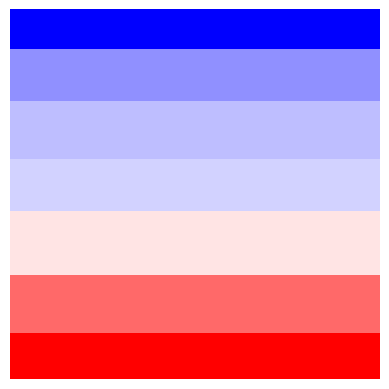

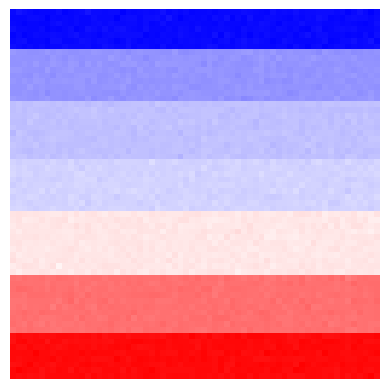

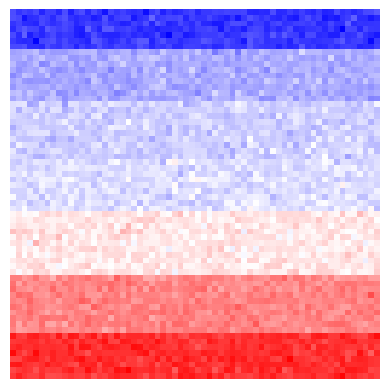

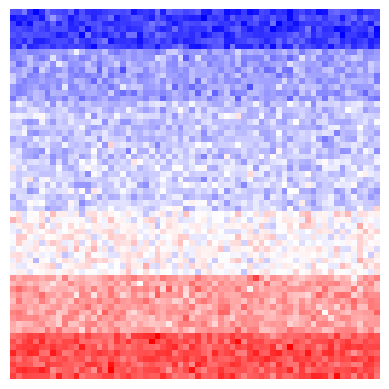

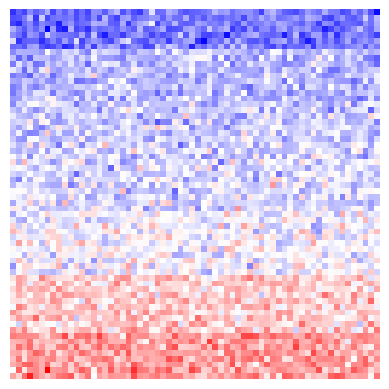

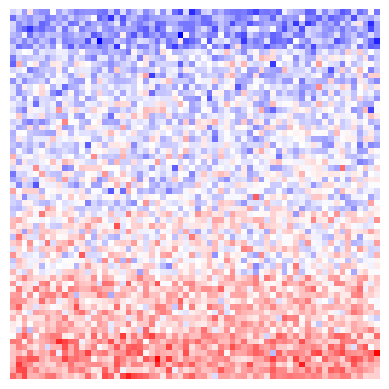

In [23]:
x=np.load("data/Vel/FlatVel_A/model/model1.npy")
x=x.reshape(500,70,70,1)[457].repeat(1,axis=2)
print(x.shape)
image_size = 70

x_start = torch.tensor(x.copy()[0:64,0:64,0])
print(x_start.min())
print(x_start.max())
print(x_start.shape)
x_start=(x_start-x_start.min())/(x_start.max()-x_start.min())*2-1

gaussian_diffusion = GaussianDiffusion(timesteps=500)
plt.figure()
plt.plot()
plt.imshow(x_start,cmap="bwr")
plt.axis("off")
for idx, t in enumerate([0, 10, 20, 50, 70]):
    x_noisy = gaussian_diffusion.q_sample(x_start, t=torch.tensor([t]))
    plt.figure()
    plt.plot()
    plt.imshow(x_noisy,cmap="bwr")
    plt.axis("off")

In [24]:
batch_size = 254
timesteps = 500

# use MNIST dataset
from re import U
from torch.utils.data import TensorDataset,DataLoader
import torch

iter_v = 1
x=np.load("data/Vel/FlatVel_A/model/model1.npy")
xmin, xmax = np.abs(np.min(x)), np.abs(np.max(x))
if iter_v==1:
    train_x = torch.Tensor(((x.reshape(500,70,70,1).repeat(1,axis=3)-xmin)/(xmax-xmin)*2.0-1.0)).permute(0,3,1,2)[:,:,:64,:64]
    train_y = torch.randn(500)
else:
    train_x_ = torch.Tensor(((x.reshape(500,70,70,1).repeat(1,axis=3)-xmin)/(xmax-xmin)*2.0-1.0)).permute(0,3,1,2)[:,:,:64,:64]
    train_y_ = torch.randn(500)
    train_x = torch.cat((train_x,train_x_),axis=0)
    train_y = torch.cat((train_y,train_y_),axis=0)



print(train_x.shape)

Train_DS = TensorDataset(train_x,train_y)
train_loader= DataLoader(Train_DS,shuffle=True,batch_size = 50)

# define model and diffusion
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNetModel(
    in_channels=1,
    model_channels=96,
    out_channels=1,
    channel_mult=(1, 2, 2),
    attention_resolutions=[]
)
model.to(device)

gaussian_diffusion = GaussianDiffusion(timesteps=timesteps)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

torch.Size([500, 1, 64, 64])


In [25]:
print(timesteps)

500


In [26]:
from tqdm import tqdm
epochs = 100
for epoch in tqdm(range(epochs)):
    for step, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        
        batch_size = images.shape[0]
        images = images.to(device)
        
        # sample t uniformally for every example in the batch
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()
        
        loss = gaussian_diffusion.train_losses(model, images, t)
        
        if step % 200 == 0:
            print("Loss:", loss.item())
            
        loss.backward()
        optimizer.step()
    torch.save(model.state_dict(),'data/Vel/FlatVel_A/modelvel.pt'.format(epoch))

  0%|                                                   | 0/100 [00:00<?, ?it/s]

Loss: 1.06840980052948


  1%|▍                                          | 1/100 [00:02<03:52,  2.35s/it]

Loss: 0.08511976152658463


  2%|▊                                          | 2/100 [00:04<03:52,  2.37s/it]

...

 98%|█████████████████████████████████████████▏| 98/100 [04:02<00:04,  2.47s/it]

Loss: 0.0024689107667654753


 99%|█████████████████████████████████████████▌| 99/100 [04:05<00:02,  2.48s/it]

Loss: 0.002074382035061717


100%|█████████████████████████████████████████| 100/100 [04:07<00:00,  2.48s/it]


In [29]:
device = torch.device('cuda')
model_unet = UNetModel(
    in_channels=1,
    model_channels=96,
    out_channels=1,
    channel_mult=(1, 2, 2),
    attention_resolutions=[]
)
model_unet.to(device)
model_unet.load_state_dict(torch.load('data/Vel/FlatVel_A/modelvel.pt'))
gaussian_diffusion = GaussianDiffusion(timesteps=500)

In [30]:
generated_images = gaussian_diffusion.sample(model_unet, 64, batch_size=64, channels=1)

sampling loop time step: 100%|████████████████| 500/500 [00:41<00:00, 12.03it/s]


In [31]:
timesteps=500

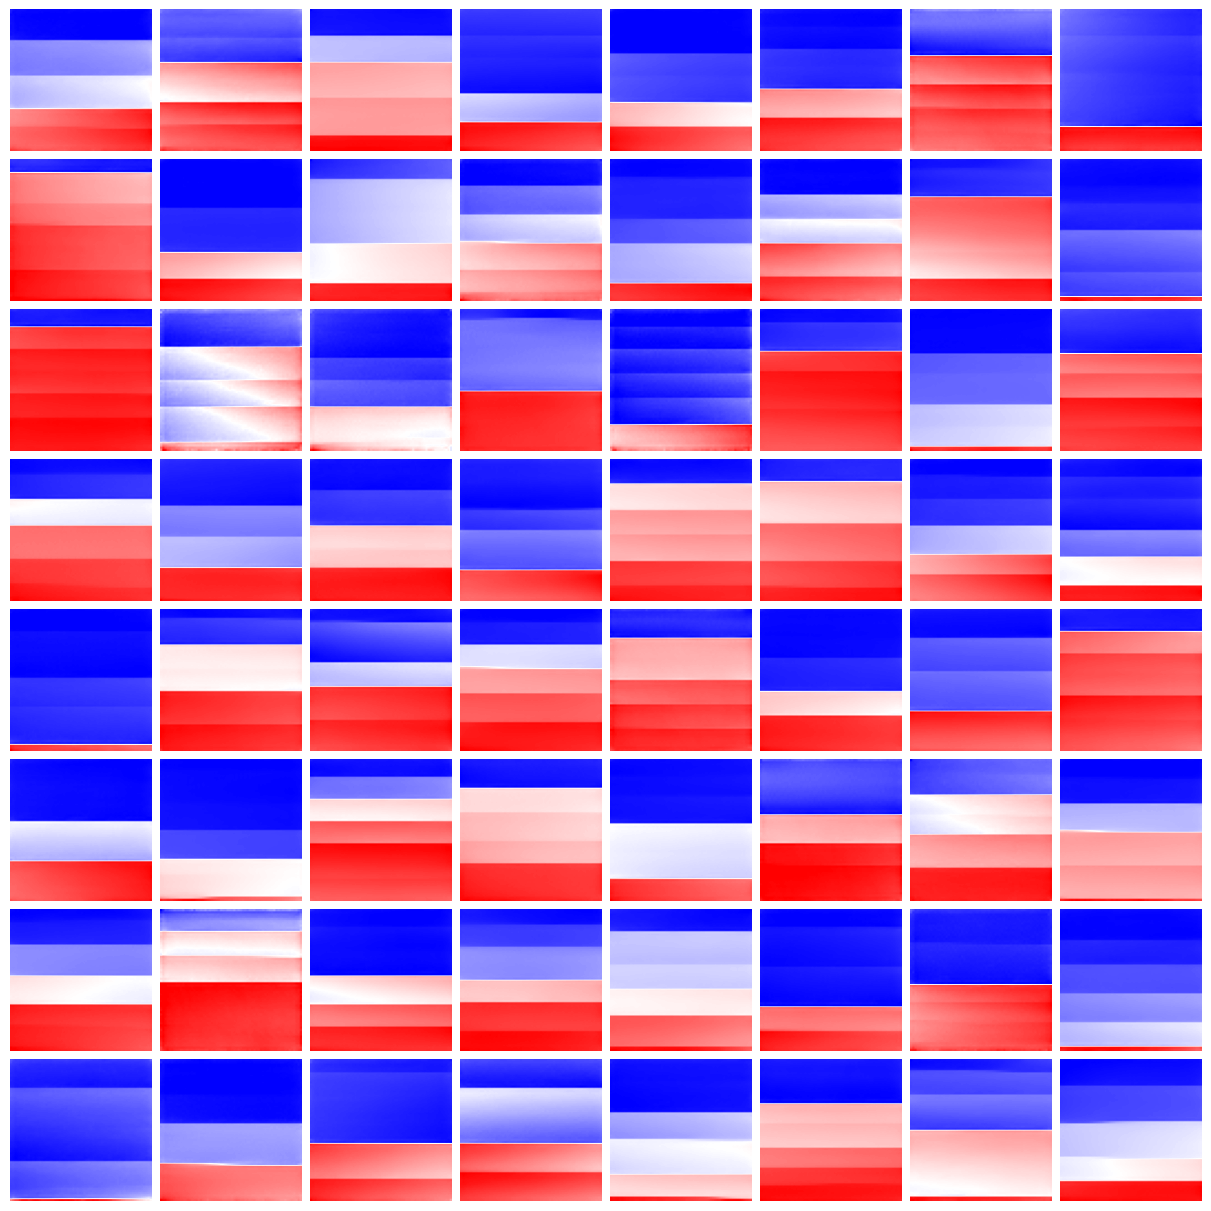

In [33]:
# generate new images
fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs = fig.add_gridspec(8, 8)

imgs = generated_images[-1].reshape(8, 8, 64, 64)
for n_row in range(8):
    for n_col in range(8):
        f_ax = fig.add_subplot(gs[n_row, n_col])
        f_ax.imshow((imgs[n_row, n_col]+1.0) * 255 / 2, cmap="bwr")
        f_ax.axis("off")

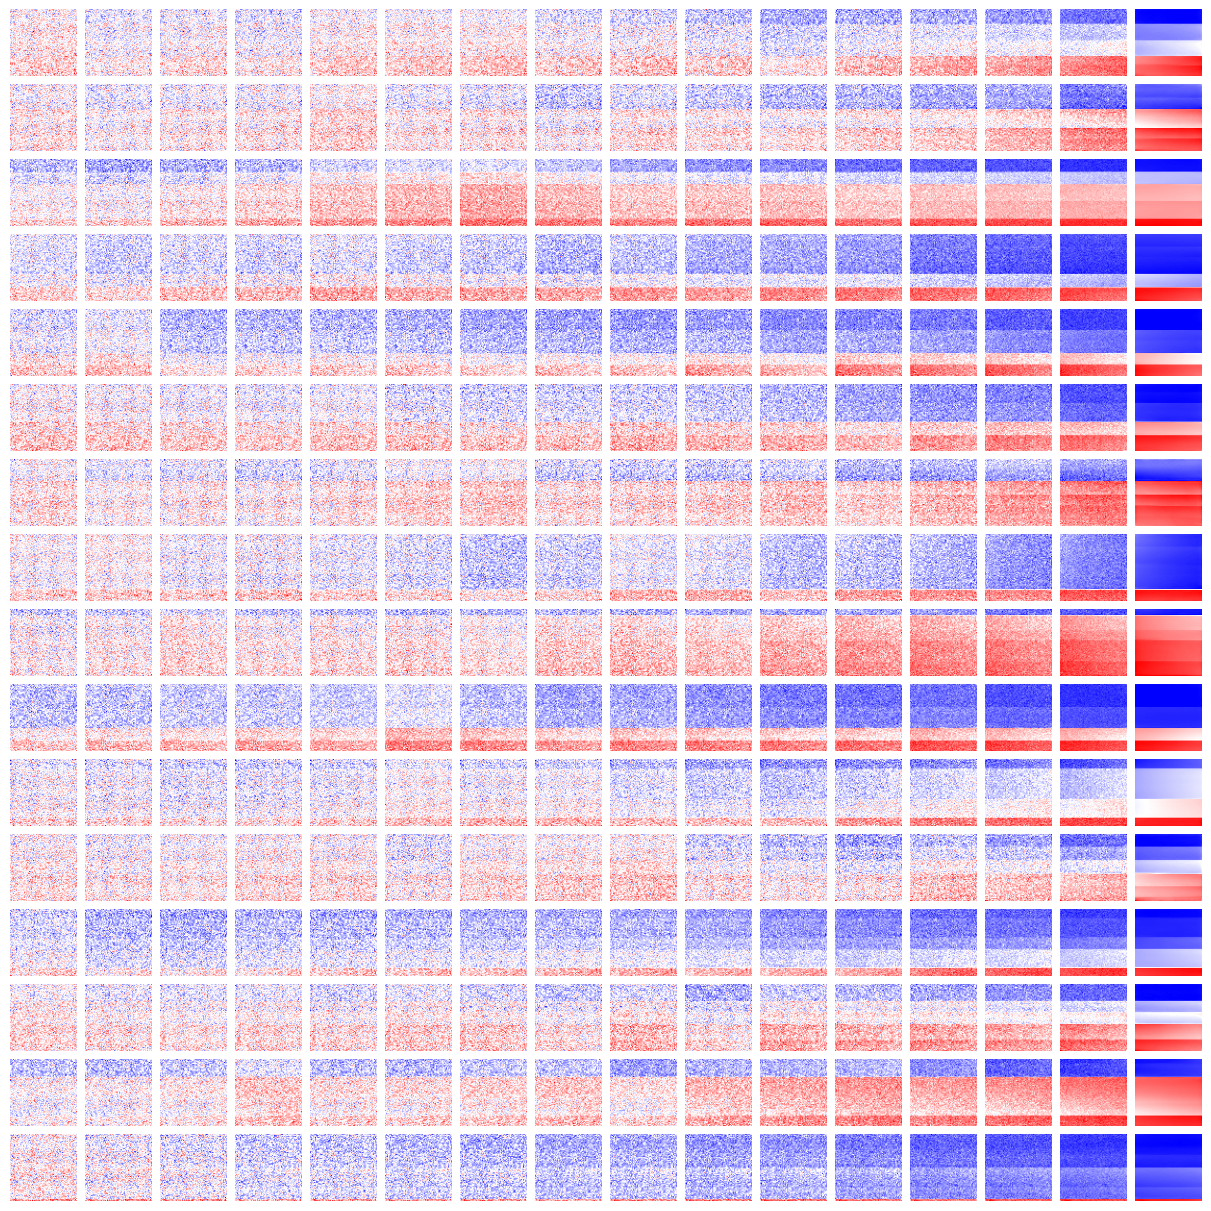

In [34]:
# show the denoise steps
fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs = fig.add_gridspec(16, 16)

for n_row in range(16):
    for n_col in range(16):
        f_ax = fig.add_subplot(gs[n_row, n_col])
        #t_idx = (timesteps// 16) * n_col if n_col < 15 else -1
        #t_idx=99+n_col*20
        t_idx = np.arange(500)[379:500:8][n_col]
        img = generated_images[t_idx][n_row].reshape(64, 64)
        f_ax.imshow((img+1.0) * 255 / 2, cmap="bwr")
        f_ax.axis("off")